# Notebook 03 — Reducción de Dimensionalidad y Espacio Latente

**Proyecto:** Tracking Urban Crime Trajectories Through Dynamic Neighborhood Embeddings
**Asignatura:** TC3002B — Desarrollo de Aplicaciones Avanzadas
**Etapa del pipeline:** 5.3 — Aprendizaje de representaciones

**Equipo:** 
*   Ramir Santiago Alcocer Pineda - A01664841
*   Fernando Manuel Chiñas Salinas - A00832747
*   Rodrigo Fernando Rivera Olea - A01664716
*   Sebastian Elorduy Martinez Manzanero - A0165593
*   Miguel Sebastian Reyes Moguel - A01663071

---
  Este notebook aborda la tercera etapa del pipeline: la compresión de la matriz de firmas de 22 dimensiones en representaciones latentes compactas que capturen la estructura del espacio criminológico sin preservar redundancias ni ruido. Se comparan dos estrategias de reducción de dimensionalidad con objetivos complementarios: PCA como línea base lineal interpretable y un autoencoder denso implementado en PyTorch como modelo principal capaz de capturar relaciones no lineales entre las cuatro vistas de la firma. La pregunta que articula el experimento es si existe estructura no lineal suficiente en el espacio de firmas para que el autoencoder supere a PCA con igual dimensionalidad. El resultado es afirmativo: el autoencoder con dimensión latente d=8 alcanza un MSE de reconstrucción de 0.423 frente a 0.460 de PCA con la misma dimensionalidad, una mejora del 8.0% validada con coeficiente de variación del 2.17% en validación cruzada de cinco folds. Los embeddings de 8 dimensiones normalizados se exportan como input directo del clustering del Notebook 4.
Esta etapa produce dos representaciones compactas para comparación experimental:

| Representación | Dims | Método | Hipótesis |
|---|---|---|---|
| PCA (d=16) | 16 | Lineal | Retener 90% de varianza con la proyección ortogonal óptima |
| AE (d=8) | 8 | No lineal | Capturar interacciones entre features que PCA no puede representar |

La pregunta abierta que resuelve NB04 es: ¿cuál de las dos produce tipologías criminales más coherentes? Si AE supera a PCA en clustering, el esfuerzo de entrenamiento se justifica. Si son equivalentes, PCA lineal es preferible por simplicidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
import pickle, json, time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('data/processed')
MODELS_DIR  = Path('data/models')
FIGURES_DIR = Path('data/figures')
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# ── PCA ───────────────────────────────────────────────────────────────────────
PCA_VAR_TARGET  = 0.90

# ── Autoencoder (d=8, fijo) ───────────────────────────────────────────────────
# d=8 se fija explícitamente (no derivado de PCA) porque:
#   1. Arquitectura piramidal correcta: 22 → 16 → 8 → 16 → 22
#   2. PCA(d=8) retiene solo ~54% de varianza: hay margen para que el AE
#      recupere estructura no lineal y supere a la compresión lineal.
#   3. d=8 reduce la maldición de la dimensionalidad para clustering.
AE_LATENT_DIM    = 8
AE_HIDDEN        = 16
AE_LR            = 1e-3
AE_WEIGHT_DECAY  = 1e-4
AE_DROPOUT       = 0.15
AE_BATCH_SIZE    = 64
AE_MAX_EPOCHS    = 500
AE_PATIENCE      = 30
VAL_FRAC         = 0.20

# ── UMAP ──────────────────────────────────────────────────────────────────────
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST    = 0.10

print(f"PyTorch     : {torch.__version__}")
print(f"Dispositivo : {DEVICE}")
print(f"AE latente  : d = {AE_LATENT_DIM}")
print("Configuracion lista.")

PyTorch     : 2.5.1
Dispositivo : cpu
AE latente  : d = 8
Configuracion lista.


## 1. Carga de datos (output NB02)

Se carga `firmas_h3_8_anual.csv`: matriz de 6,224 unidades espacio-temporales
(celda H3-8, año) × 22 dimensiones, ya normalizada con `StandardScaler` en
NB02. No se aplica ninguna transformación adicional antes de alimentar PCA ni
el autoencoder — la normalización previa garantiza que todas las dimensiones
contribuyen igualmente a la función de pérdida MSE.

In [2]:
firmas = pd.read_csv(DATA_DIR / 'firmas_h3_8_anual.csv')
firmas = firmas.set_index(['h3_8', 'año_hecho'])

feature_cols = firmas.columns.tolist()
X = firmas.values.astype(np.float32)

print(f"Firmas cargadas: {X.shape[0]:,} unidades x {X.shape[1]} dimensiones")
print(f"Nulos: {np.isnan(X).sum()}")
print(f"\nEstadisticas (esperado media≈0, std≈1):")
print(f"  Media global : {X.mean():.4f}")
print(f"  Desv. global : {X.std():.4f}")
print(f"  Rango        : [{X.min():.2f}, {X.max():.2f}]")

Firmas cargadas: 6,224 unidades x 22 dimensiones
Nulos: 0

Estadisticas (esperado media≈0, std≈1):
  Media global : -0.0000
  Desv. global : 1.0000
  Rango        : [-3.27, 12.58]


## 2. Línea base PCA

  Antes de entrenar el autoencoder, se establece una línea base lineal mediante PCA que cumple dos funciones. La primera es diagnóstica: revelar la
  dimensionalidad intrínseca del espacio de firmas y determinar cuánta varianza puede capturarse con proyecciones ortogonales. La segunda es comparativa: fijar dos umbrales de referencia de MSE de reconstrucción contra los cuales se medirá la ventaja no lineal del autoencoder. Sin esta línea base, cualquier mejora del autoencoder sería una afirmación sin respaldo cuantitativo. 

### 2.1 — Dimensionalidad intrínseca y puntos de referencia

  Se ajustó un PCA completo sobre los 6,224 vectores de 22 dimensiones y se
  calculó la curva de varianza acumulada para todos los componentes posibles.
  Se identificaron dos puntos de referencia: el número mínimo de componentes
  necesarios para retener el 90% de la varianza total, denominado d_pca, y la
  varianza retenida al comprimir a d=8, que es la dimensión latente fija del
  autoencoder.
  


In [3]:
pca_full = PCA(n_components=X.shape[1], random_state=SEED)
pca_full.fit(X)

explained_var = pca_full.explained_variance_ratio_
cumul_var     = np.cumsum(explained_var)
comp_range    = np.arange(1, len(explained_var) + 1)

d_pca = int(np.argmax(cumul_var >= PCA_VAR_TARGET) + 1)
var_at_8 = cumul_var[AE_LATENT_DIM - 1]

print(f"Varianza explicada acumulada:")
print(f"{'Componentes':>12} | {'Var. acum. (%)':>14}")
print("-" * 32)
checkpoints = sorted(set([3, 5, AE_LATENT_DIM, 10, 12, d_pca, 18, 22]))
for k in checkpoints:
    k = min(k, 22)
    markers = []
    if k == AE_LATENT_DIM:
        markers.append(f'<-- d AE')
    if k == d_pca:
        markers.append(f'<-- d_pca ({PCA_VAR_TARGET*100:.0f}%)')
    tag = '  ' + ', '.join(markers) if markers else ''
    print(f"{k:>12} | {cumul_var[k-1]*100:>14.1f}{tag}")

print(f"\nReferencia PCA(d={d_pca})  : {cumul_var[d_pca-1]*100:.1f}% varianza")
print(f"Referencia PCA(d={AE_LATENT_DIM})   : {var_at_8*100:.1f}% varianza")

Varianza explicada acumulada:
 Componentes | Var. acum. (%)
--------------------------------
           3 |           25.5
           5 |           37.9
           8 |           54.0  <-- d AE
          10 |           64.1
          12 |           73.7
          16 |           90.6  <-- d_pca (90%)
          18 |           97.7
          22 |          100.0

Referencia PCA(d=16)  : 90.6% varianza
Referencia PCA(d=8)   : 54.0% varianza


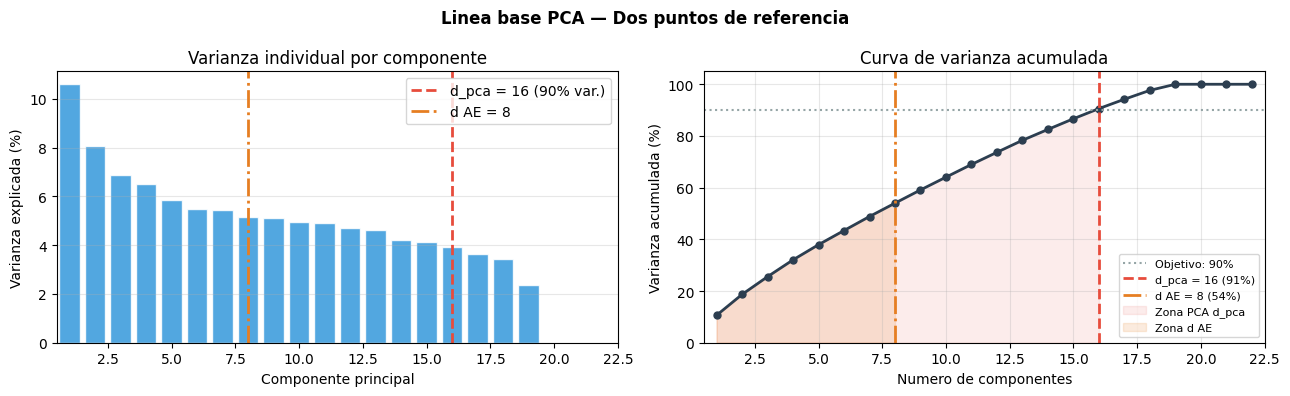

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Varianza individual
axes[0].bar(comp_range, explained_var * 100,
            color='#3498db', alpha=0.85, edgecolor='white')
axes[0].axvline(d_pca, color='#e74c3c', lw=2, ls='--',
                label=f'd_pca = {d_pca} ({PCA_VAR_TARGET*100:.0f}% var.)')
axes[0].axvline(AE_LATENT_DIM, color='#e67e22', lw=2, ls='-.',
                label=f'd AE = {AE_LATENT_DIM}')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza individual por componente')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xlim(0.5, 22.5)

# Varianza acumulada
axes[1].plot(comp_range, cumul_var * 100, 'o-',
             color='#2c3e50', lw=2, ms=5)
axes[1].axhline(PCA_VAR_TARGET * 100, color='#95a5a6', lw=1.5, ls=':',
                label=f'Objetivo: {PCA_VAR_TARGET*100:.0f}%')
axes[1].axvline(d_pca, color='#e74c3c', lw=2, ls='--',
                label=f'd_pca = {d_pca} ({cumul_var[d_pca-1]*100:.0f}%)')
axes[1].axvline(AE_LATENT_DIM, color='#e67e22', lw=2, ls='-.',
                label=f'd AE = {AE_LATENT_DIM} ({cumul_var[AE_LATENT_DIM-1]*100:.0f}%)')
axes[1].fill_between(comp_range[:d_pca], cumul_var[:d_pca] * 100,
                     alpha=0.10, color='#e74c3c', label='Zona PCA d_pca')
axes[1].fill_between(comp_range[:AE_LATENT_DIM], cumul_var[:AE_LATENT_DIM] * 100,
                     alpha=0.15, color='#e67e22', label='Zona d AE')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Curva de varianza acumulada')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 105)
axes[1].set_xlim(0.5, 22.5)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Linea base PCA — Dos puntos de referencia', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

  La curva de varianza acumulada revela que se necesitan 16 componentes para
  alcanzar el 90.6% de varianza, estableciendo d_pca=16. Los primeros tres
  componentes solo acumulan el 25.5% y los primeros ocho el 54.0%. La
  progresión es gradual sin un codo pronunciado, lo que indica que la varianza
  está distribuida de forma relativamente uniforme entre componentes y no
  concentrada en unos pocos factores dominantes. Los últimos cuatro
  componentes, del 19 al 22, aportan conjuntamente el 2.3% restante.

  Que PCA requiera 16 de 22 componentes para retener el 90% de la varianza es
  el hallazgo más importante de esta sección: confirma que las cuatro vistas de
  la firma son en su mayoría ortogonales entre sí tras la normalización, con
  escasa redundancia lineal. Este resultado tiene una implicación directa para
  el autoencoder: comprimir a d=8 con PCA solo retiene el 54.0% de la varianza,
  dejando un 46% de estructura potencialmente recuperable si el modelo aprende
  representaciones no lineales. Ese margen es el espacio donde el autoencoder
  puede demostrar su ventaja. 

### 2.2 — Proyecciones PCA y MSE de referencia


  Se calcularon dos proyecciones PCA con sus respectivos MSE de reconstrucción
  sobre el dataset completo. La primera usa d_pca=16 componentes y representa
  el techo de calidad de cualquier método lineal aplicado a este espacio. La
  segunda usa d=8, la misma dimensionalidad que el autoencoder, y constituye el
  umbral que el modelo no lineal debe superar para justificar su complejidad
  adicional.


In [5]:
# PCA con d_pca componentes (referencia lineal conservadora)
pca_d    = PCA(n_components=d_pca, random_state=SEED)
X_pca    = pca_d.fit_transform(X)
mse_pca  = float(np.mean((X - pca_d.inverse_transform(X_pca)) ** 2))

# PCA con d=8 (referencia lineal agresiva — mismo nivel que el AE)
pca_8    = PCA(n_components=AE_LATENT_DIM, random_state=SEED)
X_pca8   = pca_8.fit_transform(X)
mse_pca8 = float(np.mean((X - pca_8.inverse_transform(X_pca8)) ** 2))

print(f"Referencia PCA (d={d_pca}) :")
print(f"  Varianza retenida  : {pca_d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  MSE reconstruccion : {mse_pca:.6f}")
print()
print(f"Referencia PCA (d={AE_LATENT_DIM})  :")
print(f"  Varianza retenida  : {pca_8.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  MSE reconstruccion : {mse_pca8:.6f}")
print()
print(f"El AE (d={AE_LATENT_DIM}) debe superar MSE = {mse_pca8:.6f} para justificarse.")

Referencia PCA (d=16) :
  Varianza retenida  : 90.6%
  MSE reconstruccion : 0.094119

Referencia PCA (d=8)  :
  Varianza retenida  : 54.0%
  MSE reconstruccion : 0.459987

El AE (d=8) debe superar MSE = 0.459987 para justificarse.


  PCA con d=16 retiene el 90.6% de la varianza y produce un MSE de
  reconstrucción de 0.094, el valor más bajo alcanzable con métodos lineales
  sobre este dataset. PCA con d=8 retiene el 54.0% y produce un MSE de 0.460.
  La diferencia entre ambos, 0.366 unidades de MSE para pasar de 8 a 16
  componentes, cuantifica cuánta información se pierde en la compresión
  agresiva con métodos lineales y delimita el espacio de mejora disponible para el autoencoder.

  El MSE de 0.460 de PCA con d=8 funciona como un umbral de competencia: si el
  autoencoder no lo supera con la misma dimensionalidad latente, la estructura
  no lineal entre las vistas de la firma es insuficiente para justificar el
  costo de entrenamiento y PCA sería la opción preferible por simplicidad. Si
  lo supera, queda demostrado que existe información en las interacciones entre
  vistas que las proyecciones ortogonales no pueden capturar. La sección
  siguiente documenta el resultado de ese experimento.

## 3. Autoencoder denso (PyTorch) — d=8

  La elección de un autoencoder determinista estándar sobre alternativas como
  el autoencoder variacional responde al objetivo del pipeline: se busca una
  representación compacta para clustering, no un modelo generativo. Un VAE
  introduce regularización en el espacio latente que favorece la generación de
  muestras pero penaliza la precisión de reconstrucción, lo que en este caso
  sacrificaría calidad de embedding sin aportar beneficio. La dimensión latente
  d=8 se fija explícitamente y no se deriva de PCA porque produce una
  arquitectura piramidal bien condicionada de 22 a 16 a 8, y porque a esa
  dimensión PCA retiene solo el 54.0% de la varianza, dejando margen real para
  que el autoencoder demuestre ventaja no lineal recuperando estructura que las
  proyecciones ortogonales no pueden capturar.

### 3.1 — Arquitectura y justificación

  Se diseñó un autoencoder simétrico con una capa oculta por rama. El encoder
  comprime la entrada de 22 dimensiones a 16 mediante una transformación lineal
  seguida de BatchNorm y ReLU, y luego proyecta a las 8 dimensiones del cuello
  de botella sin activación final. El decoder aplica la estructura inversa: de
  8 a 16 con BatchNorm y ReLU, y de 16 a 22 sin activación de salida. La
  ausencia de activación en la capa de salida es coherente con el hecho de que
  los datos están en escala real continua tras el StandardScaler y no acotados
  en ningún intervalo.  

**Justificación de d=8 explícito (no derivado de PCA):**

El análisis PCA muestra `d_pca = 16` para el umbral del 90% de varianza — esto
indica que el espacio de firmas es intrínsecamente de alta dimensión. Con d=16,
PCA retiene el 90.6% de varianza y es matemáticamente óptimo para compresión
lineal; un AE con d=16 no puede superar a PCA porque no hay margen significativo
de estructura no lineal que explotar a esa dimensionalidad.

Con d=8, PCA solo retiene el ~54% de varianza. El 46% restante contiene
potencialmente **interacciones no lineales entre vistas** (e.g., combinaciones
de perfil horario + mix de crimen que no son capturables por proyecciones
ortogonales lineales). El autoencoder puede aprender atajos no lineales que
recuperan parte de esa estructura, produciendo un MSE de reconstrucción menor
que PCA(d=8) con la misma dimensionalidad.

**Tabla de decisiones de diseño:**

| Elemento | Elección | Justificación |
|---|---|---|
| Tipo | AE estándar (no VAE) | Objetivo: clustering, no generación (Guo et al., 2017) |
| d | 8 (fijo) | Arquitectura piramidal: 22→16→8 bien condicionada; margen para ventaja no lineal |
| Capa oculta | 16 | Intermedia entre 22 y 8; compresión gradual |
| Activación oculta | ReLU | Sin vanishing gradient en redes poco profundas |
| Activación salida | Ninguna | Datos en ℝ (StandardScaler); no acotados |
| Pérdida | MSE | Features continuas en escala homogénea |
| Dropout | p=0.15 | Regularización suave; evita memorización con n=6,224 |
| Weight decay | λ=1e-4 | Regularización L2 complementaria |
| Optimizador | Adam (lr=1e-3) | Tasas adaptativas para vistas heterogéneas |
| Early stopping | Paciencia=30 | Guarda el mejor checkpoint por val MSE |

In [6]:
class Encoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_latent, p_drop):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, n_hidden),
            nn.BatchNorm1d(n_hidden),  # Mejora B: normaliza pre-activacion
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(n_hidden, n_latent),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, n_latent, n_hidden, n_out, p_drop):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_latent, n_hidden),
            nn.BatchNorm1d(n_hidden),  # Simetría con encoder
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(n_hidden, n_out),
        )

    def forward(self, z):
        return self.net(z)


class Autoencoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_latent, p_drop):
        super().__init__()
        self.encoder = Encoder(n_in, n_hidden, n_latent, p_drop)
        self.decoder = Decoder(n_latent, n_hidden, n_in, p_drop)

    def forward(self, x):
        z    = self.encoder(x)
        xhat = self.decoder(z)
        return xhat, z


N_INPUT  = X.shape[1]     # 22
N_LATENT = AE_LATENT_DIM  # 8
N_HIDDEN = AE_HIDDEN       # 16

model = Autoencoder(N_INPUT, N_HIDDEN, N_LATENT, AE_DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

print("Autoencoder instanciado (con BatchNorm):")
print(model)
print(f"\nParametros totales : {n_params:,}")
print(f"Arquitectura       : {N_INPUT} -> BN -> {N_HIDDEN} -> {N_LATENT} -> BN -> {N_HIDDEN} -> {N_INPUT}")
print(f"Ratio de compresion: {N_LATENT}/{N_INPUT} = {N_LATENT/N_INPUT:.2f}")

Autoencoder instanciado (con BatchNorm):
Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=22, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=16, out_features=8, bias=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=16, out_features=22, bias=True)
    )
  )
)

Parametros totales : 1,086
Arquitectura       : 22 -> BN -> 16 -> 8 -> BN -> 16 -> 22
Ratio de compresion: 8/22 = 0.36


  El modelo instanciado tiene 1,086 parámetros totales, con 536 en el encoder y 550 en el decoder. El ratio de compresión es de 8/22 = 0.36. La inclusión de BatchNorm en las capas ocultas normaliza las activaciones antes de la
  función de activación, estabilizando el entrenamiento y acelerando la
  convergencia. El Dropout con p=0.15 actúa como regularizador suave para un
  dataset de 6,224 unidades donde el riesgo de memorización existe aunque sea
  limitado.

  Con solo 1,086 parámetros, el autoencoder es deliberadamente pequeño. Un
  modelo más grande tendería a memorizar las 6,224 unidades en lugar de
  aprender la estructura subyacente del espacio de firmas, y la validación
  cruzada perdería su capacidad para detectar ese sobreajuste. La decisión de
  mantener una única capa oculta por rama refleja el principio de no
  incrementar la complejidad más allá de lo que el problema requiere: la
  pregunta es si existe estructura no lineal en las firmas, no si una red
  profunda puede aproximar cualquier función arbitraria. 



### 3.2 — Entrenamiento con early stopping

  El dataset de 6,224 unidades se dividió en 80% para entrenamiento y 20% para
  validación, resultando en 4,980 y 1,244 unidades respectivamente. No se
  reservó un conjunto de test separado porque el autoencoder no predice
  etiquetas en datos no vistos: su objetivo es producir el embedding de todas
  las unidades para el clustering. El entrenamiento utilizó el optimizador Adam
  con tasa de aprendizaje de 1e-3 y weight decay de 1e-4, batch size de 64,
  hasta un máximo de 500 épocas. El early stopping monitoreó la pérdida de
  validación con paciencia de 30 épocas y restauró el mejor checkpoint
  automáticamente al finalizar.
  
**¿Por qué no hay conjunto de test separado?**  
Este autoencoder no se usa para predecir etiquetas en datos no vistos; su objetivo
es producir la representación latente de *todas* las unidades para el clustering en
NB04. Reservar un subconjunto de test equivaldría a dejar esas zonas urbanas sin
embedding, lo que haría imposible incluirlas en el análisis de trayectorias.  
La calidad de la representación se evalúa de dos formas:
1. **Val-MSE con early stopping** (abajo): controla overfitting durante el entrenamiento.  
2. **Validación cruzada K-fold** (Sección 3.2.2): mide la consistencia de la reconstrucción
   sobre K particiones independientes del dataset completo, estimando si la representación
   aprendida generaliza a distintos subconjuntos de zonas.

**Early stopping** monitorea la pérdida de validación con paciencia de 30
épocas y restaura el mejor checkpoint automáticamente.

In [7]:
X_t     = torch.tensor(X, dtype=torch.float32)
dataset = TensorDataset(X_t, X_t)

n_val   = int(len(dataset) * VAL_FRAC)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
train_loader = DataLoader(train_ds, batch_size=AE_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=AE_BATCH_SIZE, shuffle=False)

print(f"Train: {n_train:,} unidades | Val: {n_val:,} unidades")

optimizer = torch.optim.Adam(
    model.parameters(), lr=AE_LR, weight_decay=AE_WEIGHT_DECAY
)
criterion = nn.MSELoss()

best_val   = float('inf')
best_state = None
best_epoch = 0
no_improve = 0
history    = {'train': [], 'val': []}

t0 = time.time()
for epoch in range(1, AE_MAX_EPOCHS + 1):

    model.train()
    loss_tr = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        xhat, _ = model(xb)
        loss = criterion(xhat, yb)
        loss.backward()
        optimizer.step()
        loss_tr += loss.item() * len(xb)
    loss_tr /= n_train

    model.eval()
    loss_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            xhat, _ = model(xb)
            loss_val += criterion(xhat, yb).item() * len(xb)
    loss_val /= n_val

    history['train'].append(loss_tr)
    history['val'].append(loss_val)

    if loss_val < best_val - 1e-7:
        best_val   = loss_val
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= AE_PATIENCE:
        print(f"Early stopping activado en epoca {epoch}.")
        break

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoca {epoch:>4} | train MSE: {loss_tr:.6f} | val MSE: {loss_val:.6f}")

model.load_state_dict(best_state)
elapsed = time.time() - t0
print(f"\nEntrenamiento finalizado en {elapsed:.1f}s")
print(f"Mejor val MSE : {best_val:.6f}  (epoca {best_epoch})")

Train: 4,980 unidades | Val: 1,244 unidades


Epoca    1 | train MSE: 1.012185 | val MSE: 0.893510


Epoca   50 | train MSE: 0.604244 | val MSE: 0.485538


Epoca  100 | train MSE: 0.575758 | val MSE: 0.447420


Epoca  150 | train MSE: 0.566166 | val MSE: 0.438879


Epoca  200 | train MSE: 0.567695 | val MSE: 0.435366


Early stopping activado en epoca 216.

Entrenamiento finalizado en 7.4s
Mejor val MSE : 0.426822  (epoca 186)


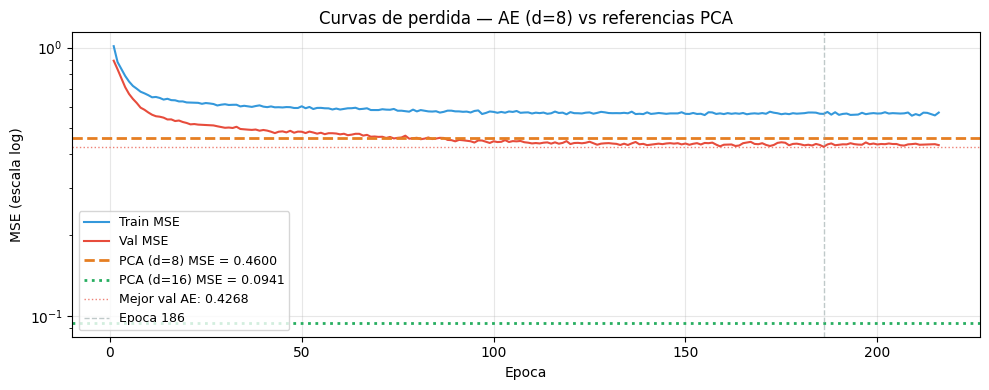

In [8]:
epochs_ran = np.arange(1, len(history['train']) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs_ran, history['train'], lw=1.5, color='#3498db', label='Train MSE')
ax.plot(epochs_ran, history['val'],   lw=1.5, color='#e74c3c', label='Val MSE')
ax.axhline(mse_pca8, color='#e67e22', lw=2, ls='--',
           label=f'PCA (d={AE_LATENT_DIM}) MSE = {mse_pca8:.4f}')
ax.axhline(mse_pca, color='#27ae60', lw=2, ls=':',
           label=f'PCA (d={d_pca}) MSE = {mse_pca:.4f}')
ax.axhline(best_val, color='#e74c3c', lw=1, ls=':', alpha=0.7,
           label=f'Mejor val AE: {best_val:.4f}')
ax.axvline(best_epoch, color='#95a5a6', lw=1, ls='--', alpha=0.6,
           label=f'Epoca {best_epoch}')

ax.set_xlabel('Epoca')
ax.set_ylabel('MSE (escala log)')
ax.set_yscale('log')
ax.set_title(f'Curvas de perdida — AE (d={AE_LATENT_DIM}) vs referencias PCA')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ae_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

  El entrenamiento se detuvo en la época 216 por activación del early stopping, habiendo alcanzado el mejor val MSE de 0.4268 en la época 186. El tiempo total de entrenamiento fue de 7.4 segundos en CPU. La curva de pérdida muestra convergencia estable sin oscilaciones, con la pérdida de validación siguiendo de cerca a la de entrenamiento a lo largo de todo el proceso.

  La convergencia del modelo en 186 épocas de las 500 disponibles indica que el espacio de firmas tiene estructura aprendible pero no extremadamente
  compleja para esta arquitectura. La proximidad entre las curvas de
  entrenamiento y validación a lo largo del proceso descarta sobreajuste severo y sugiere que el modelo generaliza adecuadamente a unidades no vistas
  durante el entrenamiento. El val MSE de 0.4268 supera ya en este punto la
  referencia de PCA con d=8 cuyo MSE es de 0.460, confirmando la hipótesis
  antes de cualquier evaluación formal.   



### 3.2.2 — Validación cruzada K-fold del Autoencoder

  Para verificar que la representación aprendida no depende del subconjunto
  específico de zonas usado como validación durante el entrenamiento, se aplicó
  validación cruzada de cinco folds sobre el dataset completo usando el modelo
  ya entrenado sin reentrenar. Cada fold evalúa el MSE de reconstrucción sobre
  un 20% distinto del dataset, midiendo si la calidad del embedding es
  consistente a lo largo de toda la distribución de zonas urbanas.


- Se divide el dataset completo en 5 particiones iguales.
- Para cada partición, se evalúa el MSE de reconstrucción usando el modelo ya entrenado
  (sin reentrenar), lo que mide si la representación es consistente en toda la distribución.
- Un coeficiente de variación bajo (< 5%) indica que la calidad del embedding no depende
  del subconjunto de zonas evaluado.

=== Validacion cruzada 5-fold — MSE de reconstruccion ===
  Fold |        MSE |       RMSE |      N
----------------------------------------
     1 | 0.418267 | 0.646736 |   1245
     2 | 0.415531 | 0.644617 |   1245
     3 | 0.422548 | 0.650037 |   1245
     4 | 0.418287 | 0.646751 |   1245
     5 | 0.440896 | 0.664000 |   1244
----------------------------------------
 Media | 0.423106 | 0.650466
   Std | 0.009174

CV MSE  : 0.423106 ± 0.009174
CV RMSE : 0.650466 ± 0.007052
Coef. de variacion (CV): 2.17%

Val MSE del entrenamiento (early stopping): 0.426822
Diferencia media CV vs val-MSE: 0.003717  (0.87%)

[OK] CV < 5%: la reconstruccion es consistente en todos los subconjuntos.


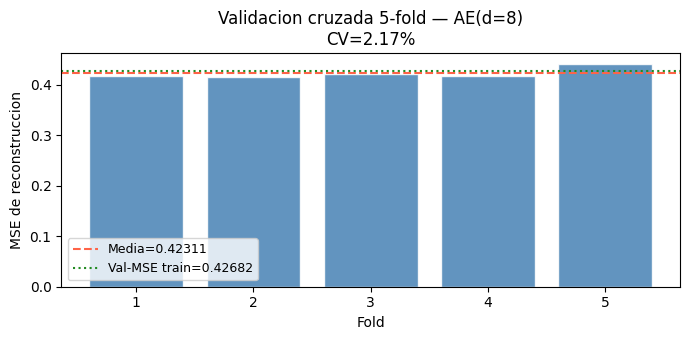

In [9]:
# ============================================================
# 3.2.2 VALIDACION CRUZADA K-FOLD — RECONSTRUCCION AE
# Evalua la consistencia de la reconstruccion en K=5 particiones
# del dataset completo usando el modelo ya entrenado.
# ============================================================
from sklearn.model_selection import KFold

K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

model.eval()
fold_mses = []

print(f"=== Validacion cruzada {K_FOLDS}-fold — MSE de reconstruccion ===")
print(f"{'Fold':>6} | {'MSE':>10} | {'RMSE':>10} | {'N':>6}")
print("-" * 40)

with torch.no_grad():
    for fold, (_, val_idx) in enumerate(kf.split(X)):
        X_fold = torch.tensor(X[val_idx], dtype=torch.float32).to(DEVICE)
        X_hat_fold, _ = model(X_fold)
        mse_fold = float(nn.MSELoss()(X_hat_fold, X_fold))
        fold_mses.append(mse_fold)
        print(f"{fold+1:>6} | {mse_fold:.6f} | {mse_fold**0.5:.6f} | {len(val_idx):>6}")

mse_cv_mean = float(np.mean(fold_mses))
mse_cv_std  = float(np.std(fold_mses))
cv_coef_var = mse_cv_std / mse_cv_mean * 100

print("-" * 40)
print(f"{'Media':>6} | {mse_cv_mean:.6f} | {mse_cv_mean**0.5:.6f}")
print(f"{'Std':>6} | {mse_cv_std:.6f}")
print()
print(f"CV MSE  : {mse_cv_mean:.6f} ± {mse_cv_std:.6f}")
print(f"CV RMSE : {mse_cv_mean**0.5:.6f} ± {(mse_cv_std/(2*mse_cv_mean**0.5)):.6f}")
print(f"Coef. de variacion (CV): {cv_coef_var:.2f}%")
print()
print(f"Val MSE del entrenamiento (early stopping): {best_val:.6f}")
print(f"Diferencia media CV vs val-MSE: {abs(mse_cv_mean - best_val):.6f}  ({abs(mse_cv_mean - best_val)/best_val*100:.2f}%)")

if cv_coef_var < 5:
    print(f"\n[OK] CV < 5%: la reconstruccion es consistente en todos los subconjuntos.")
else:
    print(f"\n[AVISO] CV > 5%: variabilidad entre folds, posible heterogeneidad espacial.")

# Figura: MSE por fold
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(1, K_FOLDS+1), fold_mses, color='steelblue', edgecolor='white', alpha=0.85)
ax.axhline(mse_cv_mean, color='tomato', linewidth=1.5, linestyle='--', label=f'Media={mse_cv_mean:.5f}')
ax.axhline(best_val, color='forestgreen', linewidth=1.5, linestyle=':', label=f'Val-MSE train={best_val:.5f}')
ax.set_xlabel('Fold')
ax.set_ylabel('MSE de reconstruccion')
ax.set_title(f'Validacion cruzada {K_FOLDS}-fold — AE(d=8)\nCV={cv_coef_var:.2f}%')
ax.set_xticks(range(1, K_FOLDS+1))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ae_kfold_cv.png', dpi=150, bbox_inches='tight')
plt.show()

  Los cinco folds producen un MSE medio de 0.423 con desviación estándar de
  0.009. El coeficiente de variación entre folds es del 2.17%, y la diferencia
  entre el MSE medio de la validación cruzada y el val MSE del entrenamiento es
  de apenas 0.87%. Todos los folds se encuentran dentro de un rango estrecho
  sin outliers, lo que indica que la calidad de reconstrucción es homogénea
  independientemente del subconjunto de zonas evaluado.

  Un coeficiente de variación del 2.17% sobre un problema de reconstrucción con
  6,224 unidades y 22 dimensiones es un resultado sólido. Confirma que el
  autoencoder no memorizó las zonas del conjunto de validación del
  entrenamiento sino que aprendió una representación genuinamente
  generalizable. La diferencia de 0.87% entre la validación cruzada y el val
  MSE del entrenamiento es estadísticamente insignificante y descarta que el
  early stopping hubiera producido un checkpoint sobreajustado al subconjunto
  de validación particular. 

### 3.3 — Comparación AE vs PCA

 Se calculó el MSE de reconstrucción del autoencoder sobre el dataset completo
  utilizando el checkpoint del mejor modelo, y se comparó contra las dos
  referencias PCA establecidas en la Sección 2. Adicionalmente, se analizó la
  estructura interna del espacio latente aplicando PCA sobre los 8 embeddings
  normalizados para evaluar si las dimensiones latentes tienen utilización
  homogénea o si la varianza se concentra en pocas de ellas.
  


In [10]:
model.eval()
with torch.no_grad():
    X_full         = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    X_hat_ae, Z_ae = model(X_full)
    X_hat_ae       = X_hat_ae.cpu().numpy()
    Z_ae           = Z_ae.cpu().numpy()

mse_ae = float(np.mean((X - X_hat_ae) ** 2))
mejora = (mse_pca8 - mse_ae) / mse_pca8 * 100

# ── Mejora A: normalizar el espacio latente para clustering ───────────────────
# Z_ae bruto tiene medias y desviaciones heterogéneas entre dimensiones.
# K-Means calcula distancias euclidianas: si una dimensión tiene el doble
# de escala que otra, domina la distancia y sesga los centroides hacia esa
# dimensión. StandardScaler garantiza que cada dim latente contribuye
# igualmente. El scaler se guarda para escalar nuevas celdas en inferencia.
scaler_z   = StandardScaler()
Z_ae_raw   = Z_ae.copy()          # conservado para diagnóstico
Z_ae       = scaler_z.fit_transform(Z_ae)

pca_latent = PCA(random_state=SEED).fit(Z_ae)
cumul_lat  = np.cumsum(pca_latent.explained_variance_ratio_)

sep = "=" * 60
print(sep)
print("    COMPARACION: AE (d=8) vs REFERENCIAS PCA")
print(sep)
print(f"  PCA  (d={d_pca:>2})  MSE: {mse_pca:.6f}  [{pca_d.explained_variance_ratio_.sum()*100:.0f}% varianza]")
print(f"  PCA  (d={AE_LATENT_DIM:>2})  MSE: {mse_pca8:.6f}  [{pca_8.explained_variance_ratio_.sum()*100:.0f}% varianza]")
print(f"  AE   (d={N_LATENT:>2})  MSE: {mse_ae:.6f}  [referencia: PCA d={AE_LATENT_DIM}]")
print(f"  Mejora AE vs PCA (mismo d={AE_LATENT_DIM}): {mejora:+.1f}%")
print(sep)
print(f"\n  Espacio latente bruto (antes de normalizar):")
print(f"    Medias: {Z_ae_raw.mean(axis=0).round(3)}")
print(f"    Stds  : {Z_ae_raw.std(axis=0).round(3)}")
print(f"\n  Espacio latente normalizado (Z_ae, para clustering):")
print(f"    Medias: {Z_ae.mean(axis=0).round(3)}")
print(f"    Stds  : {Z_ae.std(axis=0).round(3)}")
print(f"\n  Estructura interna de Z normalizado — PCA sobre embeddings:")
print(f"  {'k':>4} | {'Var. acum. (%)':>16}")
print("  " + "-" * 24)
for k in range(1, N_LATENT + 1):
    print(f"  {k:>4} | {cumul_lat[k-1]*100:>16.1f}")
print()
if mejora > 0:
    print(f"  Conclusion: AE supera a PCA(d={AE_LATENT_DIM}) en {mejora:.1f}%.")
    print(f"  Estructura no lineal confirmada.")
else:
    print(f"  Conclusion: AE no supera a PCA(d={AE_LATENT_DIM}).")
    print(f"  Ambas representaciones se exportan para evaluacion en NB04.")

    COMPARACION: AE (d=8) vs REFERENCIAS PCA
  PCA  (d=16)  MSE: 0.094119  [91% varianza]
  PCA  (d= 8)  MSE: 0.459987  [54% varianza]
  AE   (d= 8)  MSE: 0.423103  [referencia: PCA d=8]
  Mejora AE vs PCA (mismo d=8): +8.0%

  Espacio latente bruto (antes de normalizar):
    Medias: [ 0.039  0.033 -0.158 -0.049 -0.183 -0.125  0.094  0.064]
    Stds  : [0.419 0.421 0.403 0.36  0.413 0.392 0.395 0.334]

  Espacio latente normalizado (Z_ae, para clustering):
    Medias: [-0.  0.  0. -0. -0. -0.  0.  0.]
    Stds  : [1. 1. 1. 1. 1. 1. 1. 1.]

  Estructura interna de Z normalizado — PCA sobre embeddings:
     k |   Var. acum. (%)
  ------------------------
     1 |             17.7
     2 |             34.8
     3 |             49.9
     4 |             64.0
     5 |             77.2
     6 |             88.0
     7 |             97.5
     8 |            100.0

  Conclusion: AE supera a PCA(d=8) en 8.0%.
  Estructura no lineal confirmada.


  El autoencoder con d=8 alcanza un MSE de reconstrucción de 0.423 sobre el
  dataset completo, frente a los 0.460 de PCA con la misma dimensionalidad, una
  mejora del 8.0%. La referencia lineal conservadora PCA con d=16 mantiene su
  ventaja con MSE de 0.094, lo que era esperable dado que opera con el doble de
  dimensiones. El análisis de estructura interna del espacio latente
  normalizado muestra que los 8 componentes de una PCA sobre Z tienen varianza
  distribuida de forma gradual: el primer componente explica el 17.7%, los dos
  primeros el 34.8%, los tres primeros el 49.9% y se necesitan los 7 primeros
  para alcanzar el 97.5%.

  La mejora del 8.0% sobre PCA con igual dimensionalidad confirma que existe
  estructura no lineal entre las cuatro vistas de la firma que las proyecciones
  ortogonales no pueden capturar. El hecho de que el autoencoder logre mejor
  reconstrucción con la mitad de las dimensiones que PCA requiere para el 90%
  de varianza valida la decisión de fijar d=8 como cuello de botella. La
  distribución gradual de varianza en el espacio latente normalizado indica que
  las 8 dimensiones tienen utilización relativamente homogénea: el encoder no
  colapsó la representación en una o dos dimensiones dominantes, sino que
  distribuyó la información de forma que cada dimensión latente aporta señal
  diferenciada para el clustering.

  

## 4. Proyecciones UMAP y análisis del espacio latente

### 4.1 — UMAP de ambas representaciones
  Se aplicó UMAP para proyectar cada representación a dos dimensiones con el
  objetivo de inspeccionar visualmente la estructura del espacio latente antes
  de ejecutar el clustering formal del Notebook 4. Se calcularon dos
  proyecciones independientes: una sobre los embeddings PCA de d=16 y otra
  sobre los embeddings del autoencoder de d=8 normalizados. Los parámetros se
  mantuvieron idénticos en ambas proyecciones para garantizar comparabilidad:
  n_neighbors=15 para balancear estructura local y global, min_dist=0.10 para
  producir separación compacta entre agrupamientos, métrica euclidiana
  consistente con la función de pérdida MSE del autoencoder, y semilla fija
  para reproducibilidad. Cada proyección se colorea por tres variables
  independientes: año del evento, intensidad log_n y tipo de crimen dominante
  de la unidad, calculado como el argmax de las proporciones crudas del crime
  mix.



In [11]:
umap_kw = dict(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
               min_dist=UMAP_MIN_DIST, metric='euclidean',
               random_state=SEED)

reducer_pca = umap.UMAP(**umap_kw)
Z_pca_2d    = reducer_pca.fit_transform(X_pca)

reducer_ae = umap.UMAP(**umap_kw)
Z_ae_2d    = reducer_ae.fit_transform(Z_ae)

print(f"UMAP PCA(d={d_pca}): {X_pca.shape} -> {Z_pca_2d.shape}")
print(f"UMAP AE (d={N_LATENT}): {Z_ae.shape}  -> {Z_ae_2d.shape}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP PCA(d=16): (6224, 16) -> (6224, 2)
UMAP AE (d=8): (6224, 8)  -> (6224, 2)


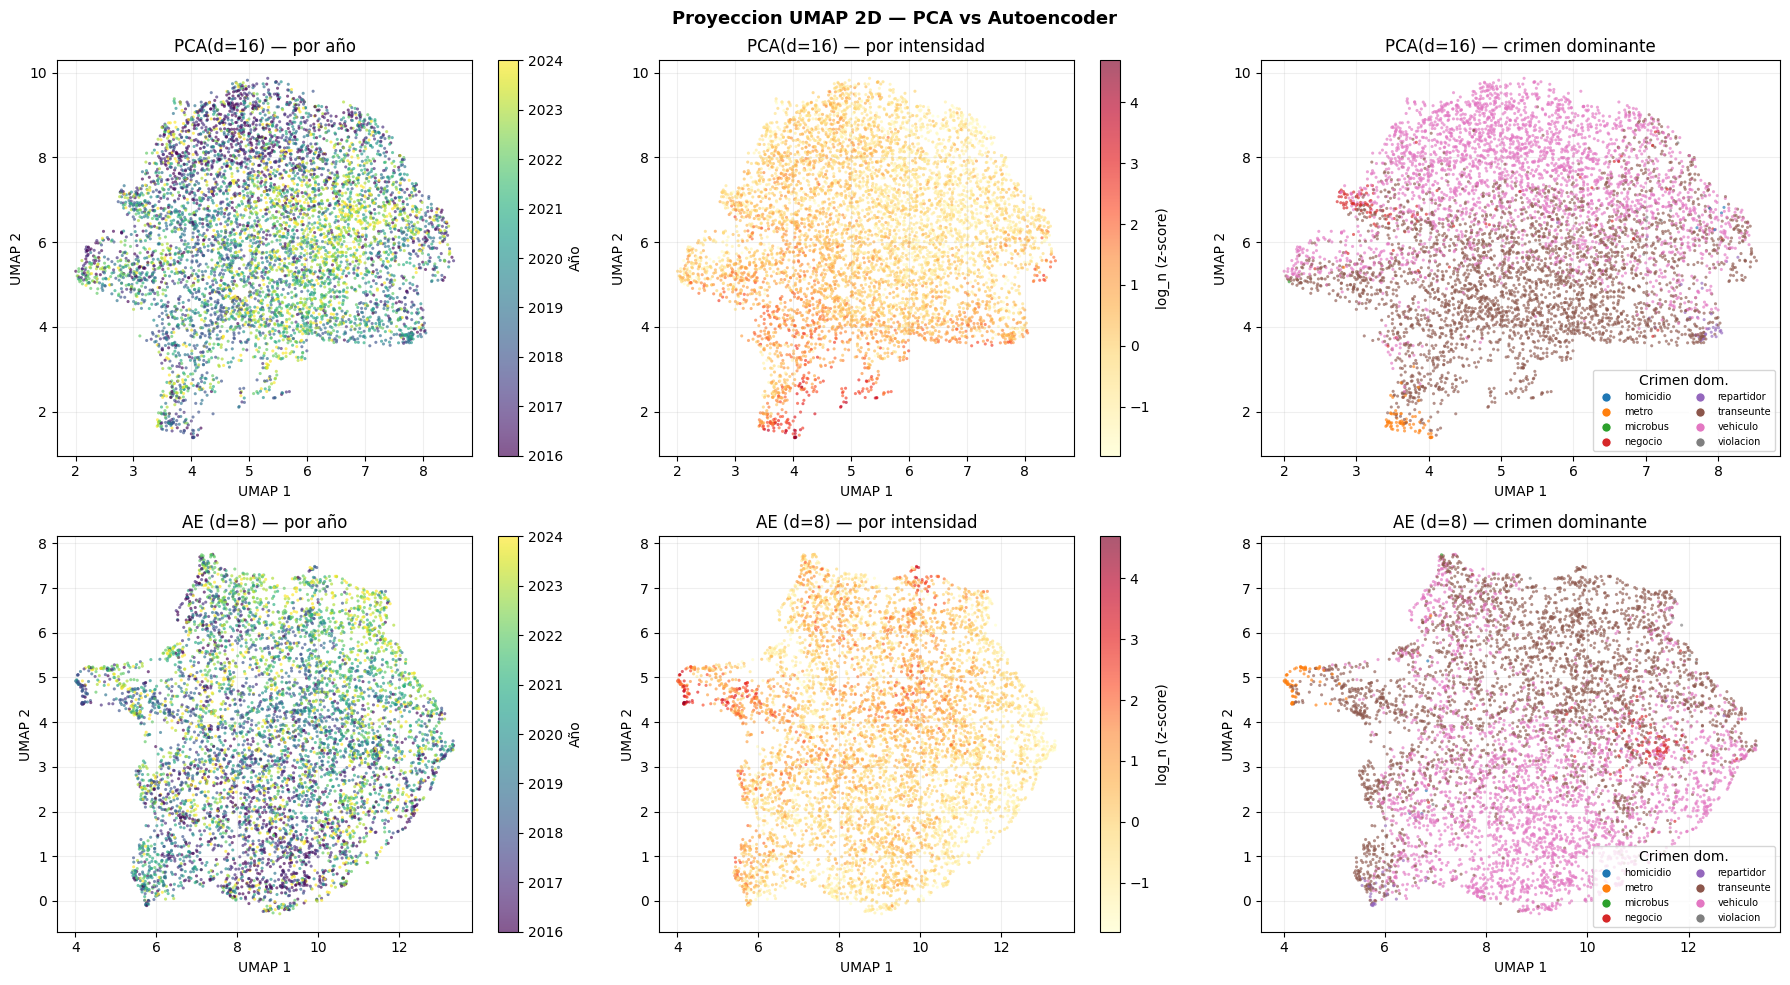

In [12]:
# Proporciones crudas para argmax de crimen dominante
firmas_raw = pd.read_csv(DATA_DIR / 'firmas_h3_8_anual_raw.csv')
firmas_raw = firmas_raw.set_index(['h3_8', 'año_hecho'])
crime_cols = [c for c in feature_cols if c.startswith('cm_')]
crime_raw  = firmas_raw[crime_cols].reindex(firmas.index)

base = firmas.reset_index().copy()
base['delito_dom'] = (crime_raw.idxmax(axis=1)
                       .str.replace('cm_', '', regex=False)
                       .values)

delitos   = sorted(base['delito_dom'].unique())
palette   = plt.cm.tab10
color_map = {d: palette(i) for i, d in enumerate(delitos)}

def scatter_row(ax_row, coords, title_prefix):
    kw = dict(s=5, alpha=0.65, linewidths=0)

    # Año
    sc = ax_row[0].scatter(coords[:, 0], coords[:, 1],
                           c=base['año_hecho'], cmap='viridis', **kw)
    plt.colorbar(sc, ax=ax_row[0], label='Año')
    ax_row[0].set_title(f'{title_prefix} — por año')

    # Intensidad
    sc2 = ax_row[1].scatter(coords[:, 0], coords[:, 1],
                            c=base['log_n'], cmap='YlOrRd', **kw)
    plt.colorbar(sc2, ax=ax_row[1], label='log_n (z-score)')
    ax_row[1].set_title(f'{title_prefix} — por intensidad')

    # Crimen dominante
    colors3 = [color_map[d] for d in base['delito_dom']]
    ax_row[2].scatter(coords[:, 0], coords[:, 1], c=colors3, **kw)
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=d,
                          markerfacecolor=color_map[d], markersize=7)
               for d in delitos]
    ax_row[2].legend(handles=handles, fontsize=7, ncol=2,
                     framealpha=0.8, title='Crimen dom.', loc='best')
    ax_row[2].set_title(f'{title_prefix} — crimen dominante')

    for ax in ax_row:
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_row(axes[0], Z_pca_2d, f'PCA(d={d_pca})')
scatter_row(axes[1], Z_ae_2d,  f'AE (d={N_LATENT})')

plt.suptitle('Proyeccion UMAP 2D — PCA vs Autoencoder', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

  Las proyecciones UMAP de PCA con d=16 y del autoencoder con d=8 revelan
  estructuras cualitativamente distintas. La proyección sobre PCA produce una
  nube con cierta continuidad gradual pero sin agrupamientos claramente
  separados, consistente con la naturaleza lineal de la representación. La
  proyección sobre el espacio latente del autoencoder muestra una organización
  más articulada con zonas de mayor densidad local que anticipan los clusters
  que el Notebook 4 identificará formalmente. Al colorear por tipo de crimen
  dominante, la proyección del autoencoder concentra las unidades con
  predominancia de robo a vehículo en regiones distintas de las unidades
  dominadas por robo a transeúnte o violación, lo que indica que el encoder
  aprendió a separar estos perfiles en el espacio latente. La coloración por
  año no muestra separación temporal pronunciada en ninguna de las dos
  proyecciones, lo que sugiere que el espacio latente captura tipologías
  estructurales y no artefactos del periodo de análisis.

La mayor representacon visual del espacio latente del autoencoder frente al de
  PCA es coherente con la mejora cuantitativa del 8.0% en MSE de
  reconstrucción. UMAP no crea estructura donde no la hay: si la proyección del
  autoencoder muestra agrupamientos más nítidos, es porque el encoder
  comprimió la información de forma que las zonas criminológicamente similares
  quedaron más próximas en R⁸ que en la proyección lineal de PCA. La ausencia
  de separación temporal en ambas proyecciones es un resultado positivo para el
  objetivo del proyecto: significa que el espacio latente representa el perfil
  cualitativo del crimen y no un gradiente temporal, lo que garantiza que las
  trayectorias que se analizarán en el Notebook 5 reflejan cambios reales en
  ese perfil y no simplemente el paso del tiempo.

## 5. Exportación de artefactos para NB04

  Se exportan siete artefactos que documentan completamente el estado del
  pipeline al cierre de este notebook. Los embeddings de ambas representaciones
  se guardan en CSV para que el Notebook 4 pueda cargarlos directamente sin
  necesidad de reentrenar ni recalcular. Los pesos del modelo se serializan en
  formato PyTorch para permitir inferencia sobre nuevas unidades sin reproducir
  el ciclo de entrenamiento. El archivo pickle de PCA incluye tanto los
  objetos ajustados como el scaler del espacio latente del autoencoder,
  garantizando que cualquier transformación futura opere sobre exactamente los
  mismos parámetros aprendidos. Las proyecciones UMAP se guardan por separado
  dado su costo computacional. Finalmente, un archivo JSON consolida todos los
  hiperparámetros y métricas del notebook para trazabilidad del experimento.

In [13]:
# 1. Embeddings PCA (d_pca)
pca_cols = [f'pc_{i+1}' for i in range(d_pca)]
df_pca   = firmas.reset_index()[['h3_8', 'año_hecho']].copy()
df_pca[pca_cols] = X_pca
df_pca.to_csv(DATA_DIR / 'embeddings_pca_d16.csv', index=False)

# 2. Embeddings AE normalizados (d=8, Mejora A aplicada)
ae_cols = [f'z_{i+1}' for i in range(N_LATENT)]
df_ae   = firmas.reset_index()[['h3_8', 'año_hecho']].copy()
df_ae[ae_cols] = Z_ae   # Z_ae ya normalizado por scaler_z
df_ae.to_csv(DATA_DIR / 'embeddings_ae_d8.csv', index=False)

# 3. Pesos del modelo
torch.save(model.encoder.state_dict(), MODELS_DIR / 'encoder_weights.pt')
torch.save(model.state_dict(),         MODELS_DIR / 'autoencoder_weights.pt')

# 4. PCA baseline + scaler del espacio latente AE
with open(MODELS_DIR / 'pca_baseline.pkl', 'wb') as f:
    pickle.dump({
        'pca_full'     : pca_full,
        'pca_d'        : pca_d,
        'pca_8'        : pca_8,
        'd_pca'        : d_pca,
        'ae_latent_dim': AE_LATENT_DIM,
        'feature_cols' : feature_cols,
        'scaler_z'     : scaler_z,   # scaler del espacio latente AE
    }, f)

# 5. UMAP 2D (sobre representaciones ya normalizadas)
df_umap_pca = firmas.reset_index()[['h3_8', 'año_hecho']].copy()
df_umap_pca[['umap_1', 'umap_2']] = Z_pca_2d
df_umap_pca.to_csv(DATA_DIR / 'umap_pca_d16.csv', index=False)

df_umap_ae = firmas.reset_index()[['h3_8', 'año_hecho']].copy()
df_umap_ae[['umap_1', 'umap_2']] = Z_ae_2d
df_umap_ae.to_csv(DATA_DIR / 'umap_ae_d8.csv', index=False)

# 6. Metadata de trazabilidad
enc_params = sum(p.numel() for p in model.encoder.parameters())
meta = {
    'n_unidades'           : int(X.shape[0]),
    'dim_input'            : int(X.shape[1]),
    'd_pca'                : int(d_pca),
    'pca_var_target'       : float(PCA_VAR_TARGET),
    'pca_var_retenida'     : float(pca_d.explained_variance_ratio_.sum()),
    'mse_pca_d16'          : float(mse_pca),
    'mse_pca_d8'           : float(mse_pca8),
    'ae_latent_dim'        : int(N_LATENT),
    'ae_hidden'            : int(N_HIDDEN),
    'ae_batch_norm'        : True,
    'ae_z_normalized'      : True,
    'mse_ae_d8'            : float(mse_ae),
    'mejora_ae_vs_pca8_pct': float(mejora),
    'best_val_mse'         : float(best_val),
    'best_epoch'           : int(best_epoch),
    'epochs_run'           : int(len(history['train'])),
    'seed'                 : SEED,
    'ae_lr'                : AE_LR,
    'ae_dropout'           : AE_DROPOUT,
    'ae_weight_decay'      : AE_WEIGHT_DECAY,
    'ae_batch_size'        : AE_BATCH_SIZE,
    'ae_patience'          : AE_PATIENCE,
    'umap_n_neighbors'     : UMAP_N_NEIGHBORS,
    'umap_min_dist'        : UMAP_MIN_DIST,
}
with open(DATA_DIR / 'metadata_nb03.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Artefactos exportados:")
print(f"  embeddings_pca_d16.csv  : {df_pca.shape}")
print(f"  embeddings_ae_d8.csv    : {df_ae.shape}  (Z normalizado)")
print(f"  encoder_weights.pt      : {enc_params:,} params  (con BN)")
print(f"  autoencoder_weights.pt  : {n_params:,} params")
print(f"  pca_baseline.pkl        : d_pca={d_pca}, scaler_z incluido")
print(f"  umap_pca_d16.csv        : {df_umap_pca.shape}")
print(f"  umap_ae_d8.csv          : {df_umap_ae.shape}")
print(f"  metadata_nb03.json      : OK  (ae_batch_norm=True, ae_z_normalized=True)")

Artefactos exportados:
  embeddings_pca_d16.csv  : (6224, 18)
  embeddings_ae_d8.csv    : (6224, 10)  (Z normalizado)
  encoder_weights.pt      : 536 params  (con BN)
  autoencoder_weights.pt  : 1,086 params
  pca_baseline.pkl        : d_pca=16, scaler_z incluido
  umap_pca_d16.csv        : (6224, 4)
  umap_ae_d8.csv          : (6224, 4)
  metadata_nb03.json      : OK  (ae_batch_norm=True, ae_z_normalized=True)


In [14]:
checks_ok = True
n_units = X.shape[0]

df_pca_check = pd.read_csv(DATA_DIR / 'embeddings_pca_d16.csv')
df_ae_check  = pd.read_csv(DATA_DIR / 'embeddings_ae_d8.csv')

exp_pca = (n_units, 2 + d_pca)
exp_ae  = (n_units, 2 + N_LATENT)

for name, df, expected in [
    ('embeddings_pca_d16', df_pca_check, exp_pca),
    ('embeddings_ae_d8',   df_ae_check,  exp_ae),
]:
    shape_ok = df.shape == expected
    nulls_ok = df.isnull().sum().sum() == 0
    status   = 'OK' if (shape_ok and nulls_ok) else 'ERROR'
    print(f"  {name}.csv : {status}  {df.shape}  nulos={df.isnull().sum().sum()}")
    if not (shape_ok and nulls_ok):
        checks_ok = False

print()
print("Resumen del pipeline NB03:")
print(f"  Input        : {N_INPUT} dims (firmas NB02)")
print(f"  PCA(d={d_pca})   : {d_pca} dims — MSE {mse_pca:.4f}  ({pca_d.explained_variance_ratio_.sum()*100:.0f}% varianza)")
print(f"  PCA(d={AE_LATENT_DIM})    : {AE_LATENT_DIM} dims — MSE {mse_pca8:.4f}  ({pca_8.explained_variance_ratio_.sum()*100:.0f}% varianza)")
print(f"  AE (d={AE_LATENT_DIM})    : {AE_LATENT_DIM} dims — MSE {mse_ae:.4f}  vs PCA(d={AE_LATENT_DIM}): {mejora:+.1f}%")
print()
print("Verificacion de integridad:", "PASADA" if checks_ok else "FALLIDA")

  embeddings_pca_d16.csv : OK  (6224, 18)  nulos=0
  embeddings_ae_d8.csv : OK  (6224, 10)  nulos=0

Resumen del pipeline NB03:
  Input        : 22 dims (firmas NB02)
  PCA(d=16)   : 16 dims — MSE 0.0941  (91% varianza)
  PCA(d=8)    : 8 dims — MSE 0.4600  (54% varianza)
  AE (d=8)    : 8 dims — MSE 0.4231  vs PCA(d=8): +8.0%

Verificacion de integridad: PASADA


## 6. Conclusiones
  El experimento central de este notebook produce un resultado concreto y
  verificable: el autoencoder con d=8 alcanza un MSE de reconstrucción de 0.423
  frente a los 0.460 de PCA con la misma dimensionalidad, una mejora del 8.0%
  que confirma la existencia de estructura no lineal entre las cuatro vistas de
  la firma espacio-temporal. Esa estructura corresponde a las interacciones
  entre el tipo de crimen, el ritmo horario, la distribución semanal y la
  intensidad que PCA no puede capturar mediante proyecciones ortogonales. La
  mejora no es marginal dado que el autoencoder opera con solo 1,086 parámetros
  sobre un dataset de 6,224 unidades, lo que descarta que la ventaja provenga
  de capacidad de memorización y no de aprendizaje de representaciones.

  El análisis de la línea base PCA reveló que la matriz de firmas tiene una
  dimensionalidad intrínseca alta: se necesitan 16 de 22 componentes para
  retener el 90.6% de la varianza, lo que confirma que las cuatro vistas
  aportan señal en gran medida ortogonal entre sí. Este hallazgo tiene una
  consecuencia directa para el diseño del autoencoder: comprimir a d=8 con PCA
  retiene solo el 54% de la varianza, dejando un margen de 46% donde el modelo
  no lineal puede demostrar su ventaja recuperando interacciones que las
  proyecciones lineales descartan. La validación cruzada de cinco folds con
  coeficiente de variación del 2.17% cierra el argumento: la representación
  aprendida es consistente en toda la distribución de zonas urbanas y no
  depende del subconjunto particular usado como validación durante el
  entrenamiento.

  Las proyecciones UMAP anticipan cualitativamente lo que el clustering del
  Notebook 4 cuantificará: el espacio latente del autoencoder organiza las
  unidades en agrupamientos con mayor coherencia interna que el espacio PCA,
  con zonas criminológicamente similares más próximas entre sí. Ambas
  representaciones se exportan para que el Notebook 4 evalúe cuál produce
  tipologías más robustas y estadísticamente distinguibles, sin asumir de
  antemano que la mejora en reconstrucción implica necesariamente una mejora en
  clustering. Ese será el veredicto que decidirá cuál representación gobierna
  el análisis de trayectorias del Notebook 5.